# calibrate_visualize.ipynb — 校准效果可视化

本 Notebook 负责：
1. 加载模型 & 校准参数
2. 构建完整期权链用于曲面可视化
3. **曲面 1**: τ × K → 期权价格（DDN vs 真实，光滑曲面）
4. **曲面 2**: τ × log(K/S₀) → 隐含波动率（DDN vs 真实，QuantLib BS 反推 IV）
5. 固定 τ 切片 IV Smile 对比（2D）

In [1]:
## Cell 1: 导入依赖 & 加载模型

import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from datetime import datetime
from scipy.interpolate import interp1d, griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import QuantLib as ql

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from modules.model       import HestonDDN
from modules.calibration import HestonCalibrator
from modules.pricing     import calculate_heston_price, compute_iv_vega_batch

# ── 加载模型 ──
MODEL_PATH = PROJECT_ROOT / "models" / "heston_ddn_weights.pth"
FALLBACK_MODEL = Path("/Users/liaojiansong/calibration/heston_ddn_weights.pth")

device = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else "cpu"
)

ckpt_path = MODEL_PATH if MODEL_PATH.exists() else FALLBACK_MODEL
ckpt  = torch.load(ckpt_path, map_location=device)
model = HestonDDN(
    input_dim        = ckpt.get('input_dim', 8),
    heston_param_dim = ckpt.get('heston_dim', 5),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.is_fitted = ckpt.get('is_fitted', True)
model.eval()
print(f"✅ 模型加载完成，设备: {device}")
print(f"   input_dim = {model.input_dim}")
print(f"   target    = {ckpt.get('target', 'unknown')}")

✅ 模型加载完成，设备: mps
   input_dim = 8
   target    = iv


In [2]:
## Cell 2: 校准参数 & 数据准备（清洗逻辑与 02_calibrate 完全一致）

DATA_DIR = Path.cwd() / "data"

# ── 筛选参数（与 02_calibrate.ipynb 保持一致） ──
DTE_LO, DTE_HI       = 40, 300
LOG_KS_LO, LOG_KS_HI = -0.15, 0.2

def interest_rate(date: str, tau: float) -> float:
    maturities = np.array([1/12, 2/12, 3/12, 6/12, 1.0])
    data = pd.read_csv('par-yield-curve-rates-2020-2023.csv')
    ir_row = data[data['date'] == date]
    market_rates = ir_row[['1 mo', '2 mo', '3 mo', '6 mo', '1 yr']].values.flatten() / 100.0
    continuous_rates = np.log(1 + market_rates * maturities) / maturities
    yield_curve = interp1d(maturities, continuous_rates, kind='cubic', fill_value='extrapolate')
    return float(yield_curve(tau))

def load_and_clean_spy(csv_path, label, n_take=200):
    """
    清洗 SPY 期权 CSV → 计算市场 IV & Vega（与 02_calibrate 完全一致）。
    输出列: r, tau, S0, K, P_mkt, log_K_S0, iv_market, vega
    仅保留 Call 期权且 IV/Vega 有效、C_VOLUME > 0 的行。
    n_take: 从中间截取的条数（默认100）。传 None 则返回全量。
    """
    dt_obj = datetime.strptime(label, "%Y-%m-%d")
    date = dt_obj.strftime("%m/%d/%Y")

    maturities = np.array([1/12, 2/12, 3/12, 6/12, 1.0])
    yield_data = pd.read_csv('par-yield-curve-rates-2020-2023.csv')
    ir_row = yield_data[yield_data['date'] == date]
    if ir_row.empty:
        raise ValueError(f"未找到日期为 {date} 的数据")
    market_rates = ir_row[['1 mo', '2 mo', '3 mo', '6 mo', '1 yr']].values.flatten() / 100.0
    continuous_rates = np.log(1 + market_rates * maturities) / maturities
    yield_curve = interp1d(maturities, continuous_rates, kind='cubic', fill_value='extrapolate')

    raw = pd.read_csv(csv_path)
    raw.columns = [c.strip().strip('[]') for c in raw.columns]
    for col in ['UNDERLYING_LAST', 'DTE', 'STRIKE', 'C_LAST', 'C_BID', 'C_ASK']:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')
    # ★ C_VOLUME: CSV 中可能为 str/空值，需先转数值
    raw['C_VOLUME'] = pd.to_numeric(raw['C_VOLUME'], errors='coerce')

    df = raw.dropna(subset=['UNDERLYING_LAST', 'DTE', 'STRIKE', 'C_LAST']).copy()
    df = df[df['C_LAST'] > 0.01].copy()
    df = df[df['UNDERLYING_LAST'] > 0].copy()
    df = df[df['C_VOLUME'].fillna(0) > 0].copy()   # ★ 确保有交易量
    df = df[(df['DTE'] >= DTE_LO) & (df['DTE'] <= DTE_HI)].copy()

    df['S0']       = df['UNDERLYING_LAST']
    df['K']        = df['STRIKE']
    df['P_mkt']    = (df['C_BID'] + df['C_ASK']) * 0.5
    df['tau']      = df['DTE'] / 365.0
    df['r']        = df['tau'].apply(lambda t: interest_rate(date, t))
    df['log_K_S0'] = np.log(df['K'] / df['S0'])

    df = df[(df['log_K_S0'] >= LOG_KS_LO) & (df['log_K_S0'] <= LOG_KS_HI)].copy()

    # ── 计算市场 IV 和 Vega ──
    iv_arr, vega_arr = compute_iv_vega_batch(
        df['P_mkt'].values, df['S0'].values, df['K'].values,
        df['tau'].values, df['r'].values,
    )
    df['iv_market'] = iv_arr
    df['vega']      = vega_arr

    # 过滤 IV/Vega 为 NaN 或 ≤ 0 的脏数据
    n_before = len(df)
    df = df.dropna(subset=['iv_market', 'vega'])
    df = df[(df['iv_market'] > 0) & (df['vega'] > 0)].copy()
    n_dropped = n_before - len(df)

    out = df[['r', 'tau', 'S0', 'K', 'P_mkt', 'log_K_S0', 'iv_market', 'vega']].reset_index(drop=True)

    # ── 自适应中间截取（与 02_calibrate 一致） ──
    if n_take is not None:
        n_actual = min(n_take, len(out))
        mid   = len(out) // 2
        start = max(0, mid - n_actual // 2)
        out   = out.iloc[start : start + n_actual].reset_index(drop=True)

    print(f"[{label}] 清洗完成: {len(out)} 条有效 Call 期权 (丢弃 {n_dropped} 条 IV 无效)")
    if len(out) == 0:
        raise ValueError(f"[{label}] 清洗后无有效数据，请检查筛选条件")
    print(f"  S0 = {out['S0'].iloc[0]:.2f},  DTE ∈ [{out['tau'].min()*365:.0f}, {out['tau'].max()*365:.0f}] 天")
    print(f"  K  ∈ [{out['K'].min():.1f}, {out['K'].max():.1f}]")
    print(f"  IV ∈ [{out['iv_market'].min():.4f}, {out['iv_market'].max():.4f}]")
    print(f"  Vega ∈ [{out['vega'].min():.2f}, {out['vega'].max():.2f}]")
    return out

def ddn_iv_batch(theta_np, df):
    """DDN 批量预测 IV（8维输入: 5 Heston + r, tau, log_K_S0）"""
    n = len(df)
    model.eval()
    with torch.no_grad():
        th   = torch.tensor(theta_np, dtype=torch.float32, device=device)
        th_e = th.unsqueeze(0).expand(n, -1)                           # (n, 5)
        r_t   = torch.tensor(df['r'].values,  dtype=torch.float32, device=device)
        tau_t = torch.tensor(df['tau'].values, dtype=torch.float32, device=device)
        lks_t = torch.tensor(df['log_K_S0'].values, dtype=torch.float32, device=device)
        mkt   = torch.stack([r_t, tau_t, lks_t], dim=1)                # (n, 3)
        X     = torch.cat([th_e, mkt], dim=1)                          # (n, 8)
        iv_pred = model(X).cpu().numpy().flatten()                      # DDN 输出 IV
    return iv_pred

# ══════════════════════════════════════════════════════════════════════
# 步骤 1: 用 200 条 9/1 数据校准
# ══════════════════════════════════════════════════════════════════════
import time

df_cal = load_and_clean_spy(DATA_DIR / 'spy_2022_09_01.csv', '2022-09-01', n_take=200)
calibrator = HestonCalibrator(model, device, seed=42)
market_dict = {
    'r':         df_cal['r'].values.astype(np.float32),
    'tau':       df_cal['tau'].values.astype(np.float32),
    'S0':        df_cal['S0'].values.astype(np.float32),
    'K':         df_cal['K'].values.astype(np.float32),
    'iv_market': df_cal['iv_market'].values,
    'vega':      df_cal['vega'].values,
}
t0 = time.time()
theta_sep1, loss_sep1, _ = calibrator.calibrate(
    market_dict, n_starts=10, lr=5e-3, max_steps=300, patience=50,
    lambda_feller=10.0, verbose=True)
T_cal = time.time() - t0

param_names = ['kappa', 'lambda', 'sigma', 'rho', 'v0']
print(f'\n校准结果 (9/1, {len(df_cal)} 条, 耗时 {T_cal:.1f}s):')
for n, v in zip(param_names, theta_sep1):
    print(f'  {n:>8s} = {v:.6f}')

# ══════════════════════════════════════════════════════════════════════
# 步骤 2: 加载 100 条 9/2 数据用于可视化验证
# ══════════════════════════════════════════════════════════════════════
df_vis = load_and_clean_spy(DATA_DIR / 'spy_2022_09_02.csv', '2022-09-02', n_take=200)
iv_ddn_vis = ddn_iv_batch(theta_sep1, df_vis)
print(f'\n✅ 可视化数据准备完成: {len(df_vis)} 条期权')

[2022-09-01] 清洗完成: 200 条有效 Call 期权 (丢弃 0 条 IV 无效)
  S0 = 396.39,  DTE ∈ [50, 120] 天
  K  ∈ [350.0, 480.0]
  IV ∈ [0.1666, 0.2621]
  Vega ∈ [0.01, 0.91]
  市场期权数   : 200
  初始点数     : 10
  Adam lr      : 0.005，max_steps=300，patience=50
  Feller λ     : 10.0
  market IV    : [0.1666, 0.2621]

  市场期权数   : 200
  初始点数     : 10
  Adam lr      : 0.005，max_steps=300，patience=50
  Feller λ     : 10.0
  market IV    : [0.1666, 0.2621]

  [start  1/10] step= 100 | loss=2.0638e-04 | Feller=✓(0.00e+00) | lr=5.00e-03
  [start  1/10] step= 100 | loss=2.0638e-04 | Feller=✓(0.00e+00) | lr=5.00e-03
  [start  1/10] step= 200 | loss=1.0059e-04 | Feller=✓(0.00e+00) | lr=5.00e-03
  [start  1/10] step= 200 | loss=1.0059e-04 | Feller=✓(0.00e+00) | lr=5.00e-03
  [start  1/10] step= 300 | loss=6.0159e-05 | Feller=✓(0.00e+00) | lr=5.00e-03
  [start  1/10] loss=6.0159e-05  [κ=3.6076, λ=0.1437, σ=1.0000, ρ=-0.6498, v₀=0.0307] Feller✓ ★
  [start  1/10] step= 300 | loss=6.0159e-05 | Feller=✓(0.00e+00) | lr=5.00e-03
  

/Users/liaojiansong/anaconda3/lib/python3.13/site-packages/py_vollib_vectorized/implied_volatility.py:75: UserWarning: Found Below Intrinsic contracts at index [51]
  below_intrinsic, above_max_price = _check_below_and_above_intrinsic(K, F, flag, undiscounted_option_price, on_error)


正在用校准参数通过 QuantLib 定价...
✅ QuantLib 定价完成: 200 条


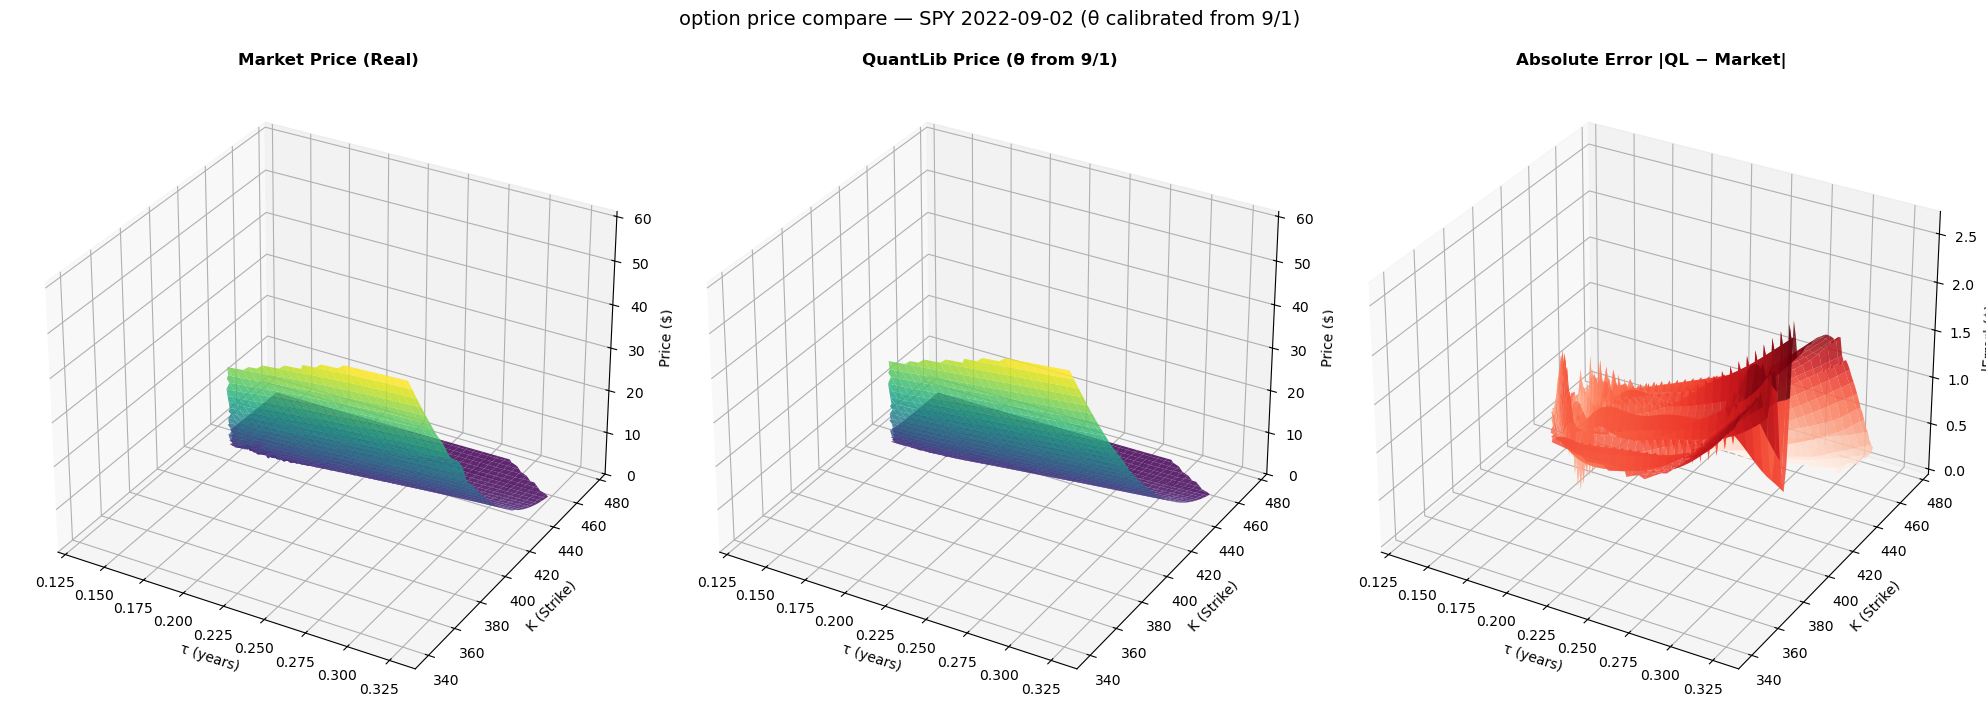

价格误差统计: 均值=$0.99, 最大=$2.29, 中位数=$1.15


In [3]:
## Cell 3: 曲面 1 — 期权价格光滑曲面 (τ × K → Price, QuantLib 定价验证)

# ── 用校准参数通过 QuantLib 逐条定价 ──
print("正在用校准参数通过 QuantLib 定价...")
P_ql_vis = []
for _, row in df_vis.iterrows():
    p = calculate_heston_price(
        float(theta_sep1[0]), float(theta_sep1[1]), float(theta_sep1[2]),
        float(theta_sep1[3]), float(theta_sep1[4]),
        float(row['r']), float(row['tau']), float(row['S0']), float(row['K']),
    )
    P_ql_vis.append(p if not np.isnan(p) else 0.0)
P_ql_vis = np.array(P_ql_vis)
print(f"✅ QuantLib 定价完成: {len(P_ql_vis)} 条")

tau_vis = df_vis['tau'].values
K_vis   = df_vis['K'].values
P_mkt_vis = df_vis['P_mkt'].values

# ── 构建规则网格并插值 ──
tau_grid = np.linspace(tau_vis.min(), tau_vis.max(), 80)
K_grid   = np.linspace(K_vis.min(), K_vis.max(), 80)
TAU_G, K_G = np.meshgrid(tau_grid, K_grid)

# 用 cubic 插值将离散点 → 光滑曲面
P_mkt_surf = griddata((tau_vis, K_vis), P_mkt_vis, (TAU_G, K_G), method='cubic')
P_ql_surf  = griddata((tau_vis, K_vis), P_ql_vis,  (TAU_G, K_G), method='cubic')

# 误差曲面
P_err_surf = np.abs(P_ql_surf - P_mkt_surf)

fig = plt.figure(figsize=(20, 7))

# ── 子图 1: 真实市场价格 ──
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(TAU_G, K_G, P_mkt_surf, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('K (Strike)', fontsize=10)
ax1.set_zlabel('Price ($)', fontsize=10)
ax1.set_title('Market Price (Real)', fontsize=12, fontweight='bold')

# ── 子图 2: QuantLib 定价（校准参数） ──
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(TAU_G, K_G, P_ql_surf, cmap='viridis', alpha=0.85, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('K (Strike)', fontsize=10)
ax2.set_zlabel('Price ($)', fontsize=10)
ax2.set_title('QuantLib Price (θ from 9/1)', fontsize=12, fontweight='bold')

# ── 子图 3: 绝对误差 ──
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(TAU_G, K_G, P_err_surf, cmap='Reds', alpha=0.85, edgecolor='none')
ax3.set_xlabel('τ (years)', fontsize=10)
ax3.set_ylabel('K (Strike)', fontsize=10)
ax3.set_zlabel('|Error| ($)', fontsize=10)
ax3.set_title('Absolute Error |QL − Market|', fontsize=12, fontweight='bold')

# 统一 Z 轴范围 (子图1 & 2)
z_lo = min(np.nanmin(P_mkt_surf), np.nanmin(P_ql_surf))
z_hi = max(np.nanmax(P_mkt_surf), np.nanmax(P_ql_surf))
ax1.set_zlim(z_lo, z_hi)
ax2.set_zlim(z_lo, z_hi)

plt.suptitle('option price compare — SPY 2022-09-02 (θ calibrated from 9/1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

price_err = np.abs(P_ql_vis - P_mkt_vis)
print(f'价格误差统计: 均值=${price_err.mean():.2f}, 最大=${price_err.max():.2f}, '
      f'中位数=${np.median(price_err):.2f}')

In [5]:
## Cell 4: 准备 IV 数据（DDN 直接输出 IV，市场 IV 已在 load_full_spy 中计算）

# ── 市场 IV 和 DDN IV 已经就绪 ──
iv_market = df_vis['iv_market'].values     # 市场 IV（由 py_vollib 从价格反算）
iv_ddn    = iv_ddn_vis                      # DDN 预测 IV（8维输入直接输出）

# 有效性检查
valid_mkt = np.isfinite(iv_market) & (iv_market > 0)
valid_ddn = np.isfinite(iv_ddn) & (iv_ddn > 0)
valid     = valid_mkt & valid_ddn
print(f'✅ IV 数据就绪: 市场有效 {valid_mkt.sum()}/{len(iv_market)}, '
      f'DDN 有效 {valid_ddn.sum()}/{len(iv_ddn)}, 共同有效 {valid.sum()}')

✅ IV 数据就绪: 市场有效 200/200, DDN 有效 200/200, 共同有效 200


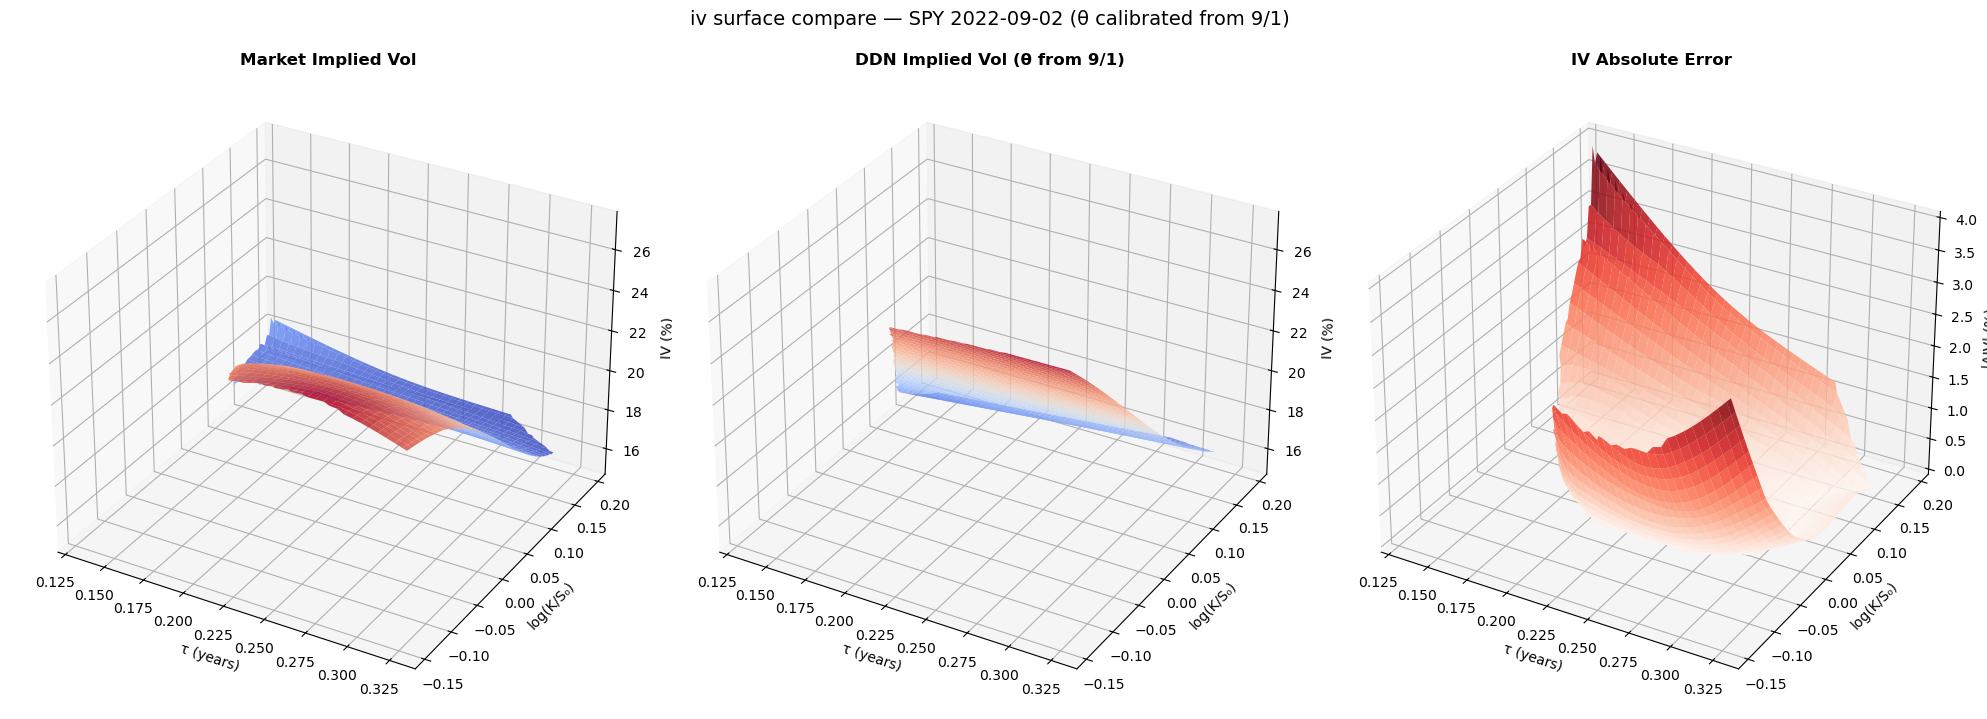

IV 误差统计: 均值=0.78%, 最大=3.85%, 中位数=0.41%


In [6]:
## Cell 5: 曲面 2 — 隐含波动率光滑曲面 (τ × log(K/S₀) → IV)

# 有效数据
tau_v  = df_vis['tau'].values[valid]
lks_v  = df_vis['log_K_S0'].values[valid]
iv_m_v = iv_market[valid] * 100   # 百分比
iv_d_v = iv_ddn[valid] * 100

# ── 构建规则网格并插值 ──
tau_grid2 = np.linspace(tau_v.min(), tau_v.max(), 80)
lks_grid  = np.linspace(lks_v.min(), lks_v.max(), 80)
TAU_G2, LKS_G = np.meshgrid(tau_grid2, lks_grid)

IV_mkt_surf = griddata((tau_v, lks_v), iv_m_v, (TAU_G2, LKS_G), method='cubic')
IV_ddn_surf = griddata((tau_v, lks_v), iv_d_v, (TAU_G2, LKS_G), method='cubic')
IV_err_surf = np.abs(IV_ddn_surf - IV_mkt_surf)

fig = plt.figure(figsize=(20, 7))

# ── 子图 1: 市场 IV 曲面 ──
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(TAU_G2, LKS_G, IV_mkt_surf, cmap='coolwarm', alpha=0.85, edgecolor='none')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('log(K/S₀)', fontsize=10)
ax1.set_zlabel('IV (%)', fontsize=10)
ax1.set_title('Market Implied Vol', fontsize=12, fontweight='bold')

# ── 子图 2: DDN IV 曲面 ──
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(TAU_G2, LKS_G, IV_ddn_surf, cmap='coolwarm', alpha=0.85, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('log(K/S₀)', fontsize=10)
ax2.set_zlabel('IV (%)', fontsize=10)
ax2.set_title('DDN Implied Vol (θ from 9/1)', fontsize=12, fontweight='bold')

# ── 子图 3: IV 误差 ──
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(TAU_G2, LKS_G, IV_err_surf, cmap='Reds', alpha=0.85, edgecolor='none')
ax3.set_xlabel('τ (years)', fontsize=10)
ax3.set_ylabel('log(K/S₀)', fontsize=10)
ax3.set_zlabel('|ΔIV| (%)', fontsize=10)
ax3.set_title('IV Absolute Error', fontsize=12, fontweight='bold')

# 统一 Z 轴范围 (子图1 & 2)
z_lo = min(np.nanmin(IV_mkt_surf), np.nanmin(IV_ddn_surf))
z_hi = max(np.nanmax(IV_mkt_surf), np.nanmax(IV_ddn_surf))
ax1.set_zlim(z_lo, z_hi)
ax2.set_zlim(z_lo, z_hi)

plt.suptitle('iv surface compare — SPY 2022-09-02 (θ calibrated from 9/1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

iv_err = np.abs(iv_d_v - iv_m_v)
print(f'IV 误差统计: 均值={iv_err.mean():.2f}%, 最大={iv_err.max():.2f}%, '
      f'中位数={np.median(iv_err):.2f}%')

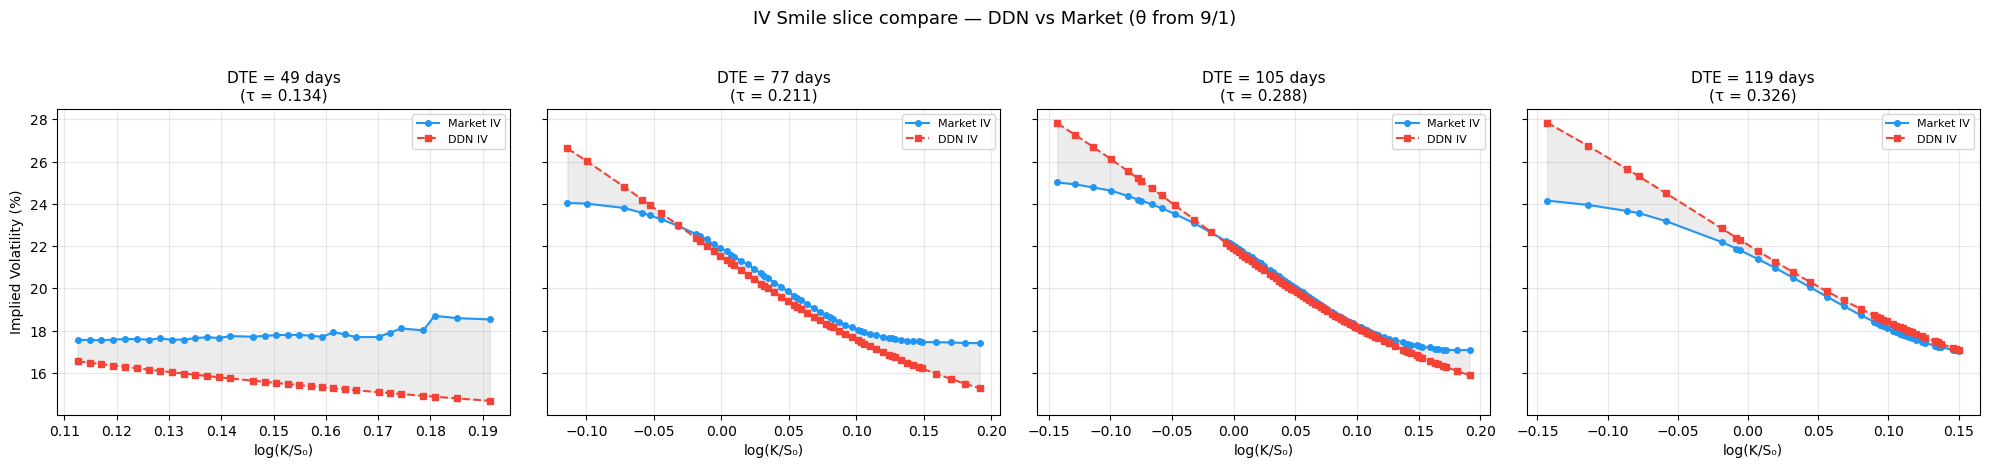

In [7]:
## Cell 6: 固定 τ 切片 — IV Smile 对比 (2D)

unique_tau = np.sort(df_vis['tau'].unique())
n_slices = min(4, len(unique_tau))
slice_idx = np.linspace(0, len(unique_tau) - 1, n_slices, dtype=int)
tau_slices = unique_tau[slice_idx]

fig, axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 4.5), sharey=True)
if n_slices == 1:
    axes = [axes]

for ax, tau_s in zip(axes, tau_slices):
    mask = (df_vis['tau'].values == tau_s) & valid
    if mask.sum() < 2:
        continue
    lks_slice = df_vis['log_K_S0'].values[mask]
    iv_m_slice = iv_market[mask] * 100
    iv_d_slice = iv_ddn[mask] * 100

    sort_idx = np.argsort(lks_slice)
    lks_s = lks_slice[sort_idx]
    iv_m_s = iv_m_slice[sort_idx]
    iv_d_s = iv_d_slice[sort_idx]

    ax.plot(lks_s, iv_m_s, 'o-', color='#2196F3', markersize=4, linewidth=1.5, label='Market IV')
    ax.plot(lks_s, iv_d_s, 's--', color='#F44336', markersize=4, linewidth=1.5, label='DDN IV')
    ax.fill_between(lks_s, iv_m_s, iv_d_s, alpha=0.15, color='gray')
    ax.set_xlabel('log(K/S₀)', fontsize=10)
    ax.set_title(f'DTE = {int(tau_s * 365)} days\n(τ = {tau_s:.3f})', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Implied Volatility (%)', fontsize=10)
plt.suptitle('IV Smile slice compare — DDN vs Market (θ from 9/1)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_61720/1699752801.py:24: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_61720/1699752801.py:24: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_61720/1699752801.py:24: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_61720/1699752801.py:24: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_rxj4x4m1f6zpb20xvl87r0000gn/T/ipykernel_61720/1699752801.py:24: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r8/fh_r

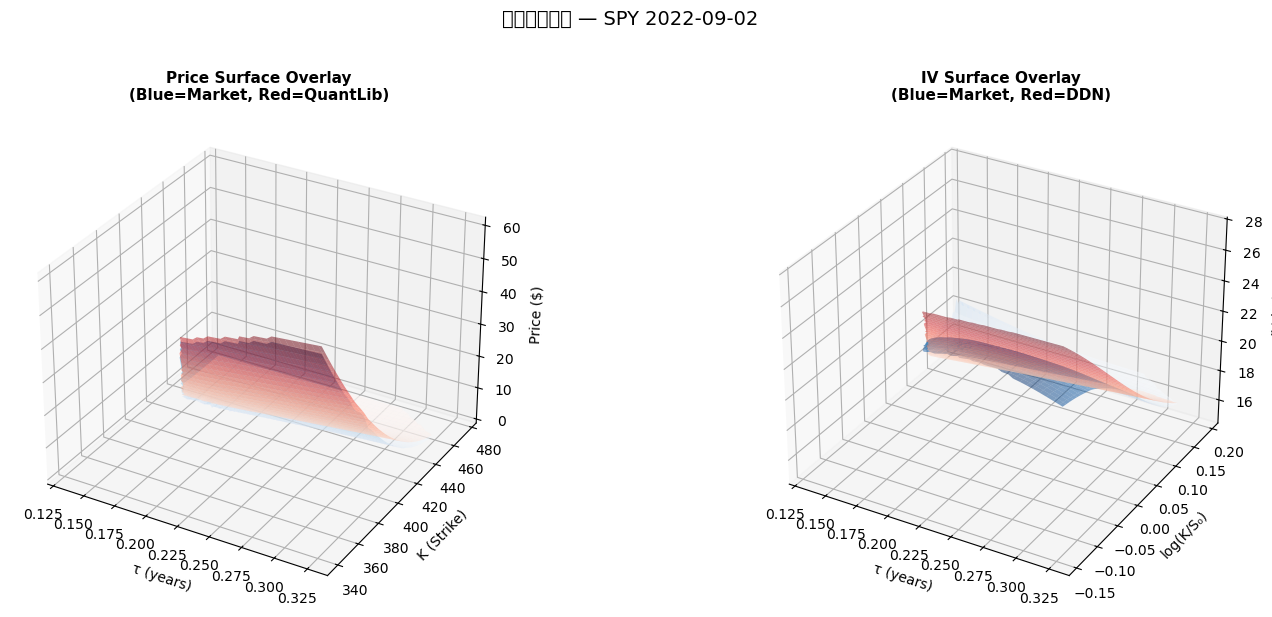

In [8]:
## Cell 7: 叠加曲面对比（Market vs Calibrated 在同一张图上）

fig = plt.figure(figsize=(16, 6))

# ── 左图: 价格曲面叠加 ──
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(TAU_G, K_G, P_mkt_surf, cmap='Blues', alpha=0.5, edgecolor='none', label='Market')
ax1.plot_surface(TAU_G, K_G, P_ql_surf,  cmap='Reds',  alpha=0.5, edgecolor='none', label='QuantLib')
ax1.set_xlabel('τ (years)', fontsize=10)
ax1.set_ylabel('K (Strike)', fontsize=10)
ax1.set_zlabel('Price ($)', fontsize=10)
ax1.set_title('Price Surface Overlay\n(Blue=Market, Red=QuantLib)', fontsize=11, fontweight='bold')

# ── 右图: IV 曲面叠加 ──
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(TAU_G2, LKS_G, IV_mkt_surf, cmap='Blues', alpha=0.5, edgecolor='none')
ax2.plot_surface(TAU_G2, LKS_G, IV_ddn_surf, cmap='Reds',  alpha=0.5, edgecolor='none')
ax2.set_xlabel('τ (years)', fontsize=10)
ax2.set_ylabel('log(K/S₀)', fontsize=10)
ax2.set_zlabel('IV (%)', fontsize=10)
ax2.set_title('IV Surface Overlay\n(Blue=Market, Red=DDN)', fontsize=11, fontweight='bold')

plt.suptitle('曲面叠加对比 — SPY 2022-09-02', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()